# Day 9: Baseline Logistic Regression Model
Train-Test Split & Evaluation using a cleaned dataset from Week 1.

## Objective
- Load the cleaned dataset
- Create a binary target variable
- Split data 80/20 without leakage
- Train a Logistic Regression model
- Evaluate accuracy on unseen test data
  

## Step 1  Import Libraries
- We import only what we need. No scaling libraries yet, scaling before split causes data leakage.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Step 2  Load the Cleaned Dataset
This is the `model_ready_features.csv` file produced during Week 1 cleaning.

In [2]:
df = pd.read_csv('model_ready_features.csv')
df.head()

,User_ID,Age,Score,Month,DayOfWeek,Is_Weekend,Dept_HR,Dept_Marketing,Dept_Sales,City_New York,City_Paris,City_Tokyo
0,1,34.967142,65.458919,1,6,1,0,0,1,0,0,0
1,2,28.617357,32.669678,1,0,0,1,0,0,1,0,0
2,3,36.476885,58.631558,1,1,0,0,0,0,0,1,0
3,4,45.230299,40.711423,1,2,0,0,0,1,0,0,1
4,5,27.658466,45.088958,1,3,0,0,0,1,0,0,1


## Step 3  Create Binary Target Variable
Logistic Regression requires a binary target. We create `Is_High_Score`: 1 if Score > 50, else 0.

In [3]:
df['Is_High_Score'] = (df['Score'] > 50).astype(int)
df['Is_High_Score'].value_counts()

Is_High_Score
1    51270
0    46294
Name: count, dtype: int64

## Step 4  Separate Features (X) and Target (y)
We drop the original `Score` column and the new target from X to avoid leakage.

In [4]:
X = df.drop(columns=['Score', 'Is_High_Score'])
y = df['Is_High_Score']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (97564, 11)
Target shape: (97564,)


## Step 5  Train-Test Split (80/20)
We split BEFORE any fitting or scaling. Using `random_state=42` for reproducibility.

Why split first? Fitting a scaler on the full dataset leaks test statistics into training.
The model indirectly sees test data, which inflates accuracy and gives a false reading.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 78051
Test samples:     19513


## Step 6 Train the Logistic Regression Model
We train only on X_train and y_train. The test set is untouched at this stage.

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## Step 7  Predict on Test Data
We generate predictions on X_test data the model has never seen.

In [7]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred[:10])
print("Actual:     ", y_test.values[:10])

Predictions: [1 1 1 1 1 1 1 1 1 1]
Actual:      [1 1 1 1 0 1 0 1 0 1]


## Step 8  Evaluate Accuracy
Accuracy = correct predictions / total test samples. This is our baseline metric.

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.2f}")

Model Accuracy on Test Set: 0.53


In [9]:
print(df['Is_High_Score'].value_counts(normalize=True))
print(df.shape)
print(X.columns.tolist())

Is_High_Score
1    0.525501
0    0.474499
Name: proportion, dtype: float64
(97564, 13)
['User_ID', 'Age', 'Month', 'DayOfWeek', 'Is_Weekend', 'Dept_HR', 'Dept_Marketing', 'Dept_Sales', 'City_New York', 'City_Paris', 'City_Tokyo']


## Linear Regression vs Decision Tree Pathways

**Logistic Regression** assumes a linear decision boundary. It calculates a weighted sum of all features and passes it through a sigmoid function to produce a probability. This means it can only separate classes with a straight line (or hyperplane in higher dimensions). If the true relationship between features and target is curved or conditional, Logistic Regression cannot capture it no matter how much data you give it.

**Random Forest** does not assume any functional form. Each decision tree in the forest splits the data through a series of yes/no questions on individual features (e.g. "Is Age > 30?", "Is City_Tokyo == 1?"). This creates a branching, non-linear decision path that can carve out irregular regions of the feature space. By averaging predictions across 100 independently trained trees (each seeing a random subset of data and features), Random Forest reduces variance and avoids relying on any single rigid assumption about the data's structure.

The core trade-off: Logistic Regression is simpler, faster, and more interpretable, but only works well when the true relationship is genuinely linear. Random Forest is more flexible and powerful on complex, non-linear, real-world data, but is computationally heavier and harder to interpret directly.

## Step 9: Random Forest Classifier
Logistic Regression assumes a linear relationship between features and target. Random Forest is an ensemble of decision trees that captures non-linear patterns through recursive splitting and majority voting. We test if it performs better on this dataset, training exclusively on X_train and y_train, the test set remains untouched until prediction.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                               classification_report, precision_score, 
                               recall_score, f1_score)
import matplotlib.pyplot as plt
import joblib

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest trained successfully.")
print("Predictions:", rf_pred[:10])
print("Actual:     ", y_test.values[:10])

Random Forest trained successfully.
Predictions: [0 1 1 1 0 0 1 0 1 1]
Actual:      [1 1 1 1 0 1 0 1 0 1]


## Step 10: Random Forest Evaluation
Accuracy alone is misleading on classification tasks. We compute Precision, Recall, and F1-Score for a complete picture of model performance.

In [11]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Random Forest Accuracy:  {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall:    {rf_recall:.4f}")
print(f"Random Forest F1-Score:  {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:  0.5024
Random Forest Precision: 0.5269
Random Forest Recall:    0.5479
Random Forest F1-Score:  0.5372

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.45      0.46      9228
           1       0.53      0.55      0.54     10285

    accuracy                           0.50     19513
   macro avg       0.50      0.50      0.50     19513
weighted avg       0.50      0.50      0.50     19513



## Step 11: Confusion Matrix
Visual breakdown of correct vs incorrect predictions for each class.

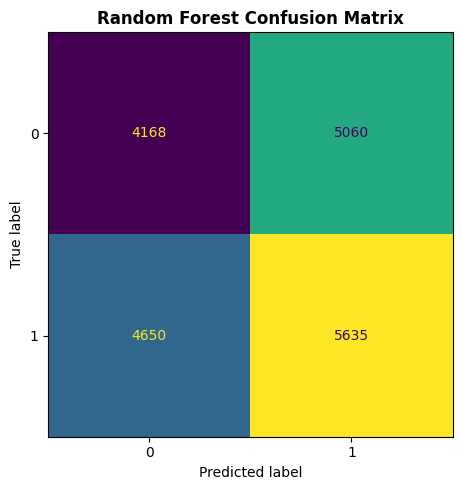

Saved rf_confusion_matrix.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax, colorbar=False)
ax.set_title('Random Forest Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved rf_confusion_matrix.png")

## Step 12: Comparison with Logistic Regression
Side-by-side comparison of both models on the same test set.

In [13]:
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"{'Metric':<15} {'Logistic Reg':<15} {'Random Forest':<15}")
print("-" * 50)
print(f"{'Accuracy':<15} {accuracy:<15.4f} {rf_accuracy:<15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred):<15.4f} {rf_precision:<15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred):<15.4f} {rf_recall:<15.4f}")
print(f"{'F1-Score':<15} {f1_score(y_test, y_pred):<15.4f} {rf_f1:<15.4f}")

MODEL COMPARISON
Metric          Logistic Reg    Random Forest  
--------------------------------------------------
Accuracy        0.5271          0.5024         
Precision       0.5271          0.5269         
Recall          1.0000          0.5479         
F1-Score        0.6903          0.5372         


## Step 13: Save Random Forest Model
Saving the trained ensemble using joblib for future inference without retraining.

In [14]:
joblib.dump(rf, 'random_forest_baseline.pkl')
print("Saved random_forest_baseline.pkl")

Saved random_forest_baseline.pkl


## Conclusion

### Results
- Logistic Regression Accuracy: 0.5271 | Recall: 1.0000 | F1: 0.6903
- Random Forest Accuracy: 0.5024 | Recall: 0.5479 | F1: 0.5372

### Why is Logistic Regression's F1 misleading
Logistic Regression's Recall of 1.0000 is a red flag, not a strength. It means the model is predicting class 1 for nearly every sample, regardless of the actual features. This inflates F1 artificially. Random Forest's more balanced precision and recall (both close to 0.53) is actually a more honest reflection of the model genuinely attempting to distinguish both classes, even though its raw accuracy is slightly lower.

### Why is overall performance low
The dataset used is synthetically generated. The features (Age, Department, City, DayOfWeek etc.) were created independently with no statistical relationship to the Score column. Because of this, neither model has real signal to learn from. Both hover near 50%, consistent with random guessing on a roughly balanced binary target.

### Why ensemble models matter despite this result
Random Forest builds multiple decision trees on random subsets of data and features, then combines their votes. This makes it more resistant to overfitting and better at capturing non-linear relationships compared to a single linear model. On a real-world dataset with genuine feature-target relationships, Random Forest would likely outperform Logistic Regression by a wider margin — this synthetic dataset simply does not give either model anything real to learn.

### What this comparison tells us
- The data pipeline works correctly — split, train, predict, evaluate all executed without data leakage for both models
- Accuracy alone would have misled us into picking Logistic Regression as the better model  F1 and Recall reveal the truth
- The problem is data quality, not model implementation
- Precision, Recall, and F1-Score together give a far more honest picture than accuracy alone, especially when a model's recall is suspiciously perfect

### Key Takeaways
- Never trust a recall of 1.0000 at face value  investigate why
- Random Forest's balanced metrics here are more trustworthy than Logistic Regression's inflated F1
- Both models confirm: model performance is only as good as the data it learns from